
# Workflow du Projet d'Analyse de Texte (Lewis Carroll)

Ce notebook suit un pipeline de Traitement du Langage Naturel (NLP) structuré comme suit :

1.  **Acquisition des Données** : Récupération des textes via l'API Gutenberg.
2.  **Prétraitement** :
    *   Nettoyage (Regex) pour enlever les en-têtes/pieds de page.
    *   Tokenisation (segmentation en mots).
    *   Filtrage (Suppression des stopwords).
3.  **Normalisation** :
    *   *Stemming* (Racinisation) : Réduction heuristique au radical.
    *   *Lemmatization* : Réduction à la forme canonique (lemme) basée sur le dictionnaire.
4.  **Analyse Statistique** :
    *   Bag of Words (BoW) pour la fréquence simple.
    *   TF-IDF pour identifier les mots discriminants.
5.  **Visualisation** : Nuages de mots (Word Clouds) et graphiques circulaires.


In [11]:
import requests
import re
import nltk
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

# Téléchargement des ressources NLTK nécessaires
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt_tab')

# Chargement du modèle spaCy
nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
urls = [
    'https://www.gutenberg.org/files/11/11-0.txt',  # Alice’s Adventures in Wonderland
    'https://www.gutenberg.org/files/12/12-0.txt',  # Through the Looking-Glass
    'https://www.gutenberg.org/ebooks/29042.txt.utf-8' # A Tangled Tale
]

def load_texts(url_list):
    corpus = []
    titles = ["Alice's Adventures in Wonderland", "Through the Looking-Glass", "A Tangled Tale"]

    for url in url_list:
        response = requests.get(url)
        text = response.text

        # 2. Nettoyage des métadonnées Gutenberg
        start_match = re.search(r'\*\*\* START OF (THIS|THE) PROJECT GUTENBERG EBOOK', text)
        end_match = re.search(r'\*\*\* END OF (THIS|THE) PROJECT GUTENBERG EBOOK', text)

        if start_match and end_match:
            text = text[start_match.end():end_match.start()]

        # Nettoyage des caractères non-alphabétiques
        cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)
        corpus.append(cleaned_text)

    return corpus, titles

corpus_raw, titles = load_texts(urls)

for i, text in enumerate(corpus_raw):
    print(f"--- {titles[i]} (200 chars) ---\n{text[:200]}\n")

--- Alice's Adventures in Wonderland (200 chars) ---
  

Illustration




Alices Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 

Contents

 CHAPTER I     Down the RabbitHole
 CHAPTER II    The Pool of Tears
 CHAPTER III   A 

--- Through the Looking-Glass (200 chars) ---
  

Illustration




THROUGH THE LOOKINGGLASS

And What Alice Found There

By Lewis Carroll

The Millennium Fulcrum Edition 




DRAMATIS PERSON
As arranged before commencement of game

WHITE         

--- A Tangled Tale (200 chars) ---
 A TANGLED TALE 




Produced by Chris Curnow Carla Foust Lindy Walsh and the
Online Distributed Proofreading Team at httpswwwpgdpnet
Music transcribed by Linda Cantoni





Transcribers 



In [13]:
# 3. Tokenisation et 4. Suppression des Stopwords
stop_words = set(stopwords.words('english'))
all_tokens = []
all_filtered_tokens = []

for i, text in enumerate(corpus_raw):
    tokens = nltk.word_tokenize(text.lower())
    all_tokens.append(tokens)

    filtered = [w for w in tokens if w not in stop_words]
    all_filtered_tokens.append(filtered)

    print(f"{titles[i]}: First 150 tokens count: {len(tokens[:150])}")
    print(f"Stopwords removed check (e.g., 'i' in tokens?): {'i' in filtered}\n")

# 5. Porter Stemmer
stemmer = PorterStemmer()
for i, tokens in enumerate(all_filtered_tokens):
    stemmed = [stemmer.stem(w) for w in tokens[:50]]
    print(f"Stemmed (first 50) - {titles[i]}:\n{stemmed}\n")

Alice's Adventures in Wonderland: First 150 tokens count: 150
Stopwords removed check (e.g., 'i' in tokens?): False

Through the Looking-Glass: First 150 tokens count: 150
Stopwords removed check (e.g., 'i' in tokens?): False

A Tangled Tale: First 150 tokens count: 150
Stopwords removed check (e.g., 'i' in tokens?): False

Stemmed (first 50) - Alice's Adventures in Wonderland:
['illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparti', 'chapter', 'viii', 'queen', 'croquetground', 'chapter', 'ix', 'mock', 'turtl', 'stori', 'chapter', 'x']

Stemmed (first 50) - Through the Looking-Glass:
['illustr', 'lookingglass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'ed

In [14]:
# 6. spaCy Lemmatization
all_lemmas = []
for i, text in enumerate(corpus_raw):
    doc = nlp(text[:10000]) # On limite pour la démo de lemmatisation sur les 50 premiers
    lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_space]
    all_lemmas.append(lemmas)
    print(f"Lemmatized (first 50) - {titles[i]}:\n{lemmas[:50]}\n")

Lemmatized (first 50) - Alice's Adventures in Wonderland:
['Illustration', 'Alices', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'content', 'chapter', 'RabbitHole', 'CHAPTER', 'II', 'Pool', 'Tears', 'CHAPTER', 'III', 'CaucusRace', 'Long', 'Tale', 'CHAPTER', 'IV', 'Rabbit', 'send', 'little', 'Bill', 'CHAPTER', 'V', 'Advice', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'Pepper', 'CHAPTER', 'VII', 'Mad', 'TeaParty', 'CHAPTER', 'VIII', 'Queens', 'CroquetGround', 'CHAPTER', 'IX', 'Mock', 'Turtles', 'Story', 'CHAPTER', 'X']

Lemmatized (first 50) - Through the Looking-Glass:
['Illustration', 'lookingglass', 'Alice', 'find', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'person', 'arrange', 'commencement', 'game', 'WHITE', 'RED', 'PIECES', 'PAWNS', 'PAWNS', 'PIECES', 'Tweedledee', 'Daisy', 'Daisy', 'Humpty', 'Dumpty', 'Unicorn', 'Haigha', 'Messenger', 'Carpenter', 'Sheep', 'Oyster', 'Oyster', 'Walrus', 'W', 'Queen', 'Lily', 'Tigerlily',

### 7. Analyse de la différence : Stemming vs Lemmatization

*   **Stemming (Porter Stemmer)** : C'est un processus brutal qui coupe la fin des mots (ex: 'arguing' devient 'argu'). C'est rapide mais peut générer des mots qui n'existent pas.
*   **Lemmatization (spaCy)** : Utilise un dictionnaire et une analyse morphologique pour revenir à la racine linguistique réelle (ex: 'was' devient 'be'). C'est plus précis car cela prend en compte le contexte du mot.

### 8 & 9. POS Tagging et Reconnaissance d'Entités Nommées (NER)

Nous utilisons NLTK pour identifier la nature grammaticale des mots (Part-of-Speech) et extraire les entités (noms propres, lieux, etc.).


In [ ]:
# 8. POS Tags - Identification de la nature grammaticale
for i, tokens in enumerate(all_tokens):
    pos_tags = nltk.pos_tag(tokens[:20])
    print(f"POS Tags (20 premiers) - {titles[i]}:\n{pos_tags}\n")

# 9. Named Entities - Identification des entités (Noms, Lieux, etc.)
for i, text in enumerate(corpus_raw):
    # On utilise spaCy pour une extraction plus robuste sur le début du texte
    doc = nlp(text[:2000])
    entities = [(ent.text.strip(), ent.label_) for ent in doc.ents if ent.text.strip()]
    print(f"Entités détectées - {titles[i]}:\n{entities[:10]}\n")

POS Tags (20 premiers) - Alice's Adventures in Wonderland:
[('illustration', 'NN'), ('alices', 'NNS'), ('adventures', 'VBZ'), ('in', 'IN'), ('wonderland', 'NN'), ('by', 'IN'), ('lewis', 'JJ'), ('carroll', 'NN'), ('the', 'DT'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('i', 'VBP'), ('down', 'RP'), ('the', 'DT'), ('rabbithole', 'NN'), ('chapter', 'NN'), ('ii', 'NN')]

POS Tags (20 premiers) - Through the Looking-Glass:
[('illustration', 'NN'), ('through', 'IN'), ('the', 'DT'), ('lookingglass', 'NN'), ('and', 'CC'), ('what', 'WP'), ('alice', 'NN'), ('found', 'VBD'), ('there', 'RB'), ('by', 'IN'), ('lewis', 'NN'), ('carroll', 'NN'), ('the', 'DT'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('dramatis', 'NN'), ('person', 'NN'), ('as', 'IN'), ('arranged', 'NN')]

POS Tags (20 premiers) - A Tangled Tale:
[('a', 'DT'), ('tangled', 'JJ'), ('tale', 'NN'), ('produced', 'VBN'), ('by', 'IN'), ('chris', 'NN'), ('curnow', 'NN

### Analyse du Texte

Nous allons maintenant visualiser les mots les plus fréquents avec des Word Clouds, puis comparer les approches Bag of Words (BoW) et TF-IDF.

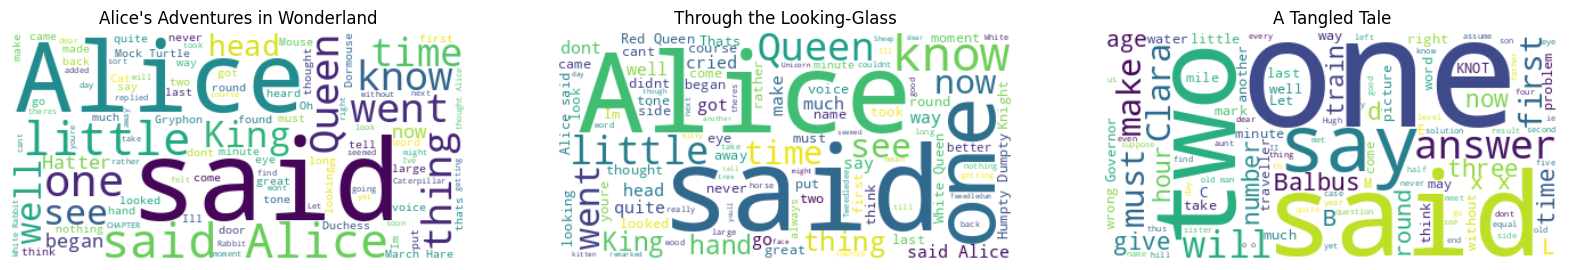


Top 5 BoW for Alice's Adventures in Wonderland:
Index: 19, Word: 'alice', Count: 23
Index: 927, Word: 'think', Count: 15
Index: 524, Word: 'little', Count: 14
Index: 137, Word: 'chapter', Count: 13
Index: 515, Word: 'like', Count: 10

Top 5 BoW for Through the Looking-Glass:
Index: 19, Word: 'alice', Count: 25
Index: 473, Word: 'kitten', Count: 16
Index: 474, Word: 'kitty', Count: 14
Index: 137, Word: 'chapter', Count: 13
Index: 924, Word: 'th', Count: 12

Top 5 BoW for A Tangled Tale:
Index: 798, Word: 'say', Count: 19
Index: 56, Word: 'balbus', Count: 14
Index: 432, Word: 'hugh', Count: 7
Index: 817, Word: 'shall', Count: 6
Index: 910, Word: 'tale', Count: 6


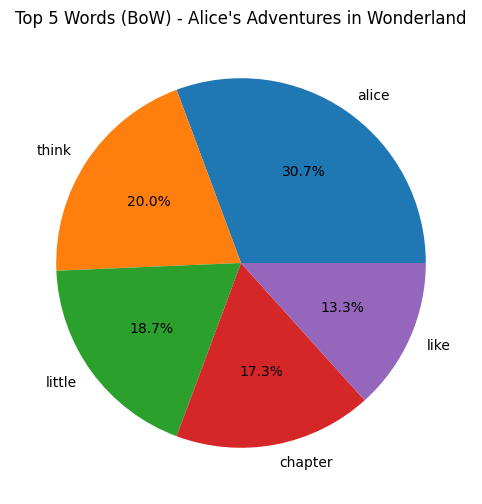

In [16]:
import numpy as np

# 1. Word Clouds
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for i, text in enumerate(corpus_raw):
    wc = WordCloud(background_color='white', max_words=100).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i])
    axes[i].axis('off')
plt.show()

# 2. BoW Method - 5 most frequent words
# On utilise les lemmes pour une meilleure analyse
vectorizer = CountVectorizer(stop_words='english')
bow_matrix = vectorizer.fit_transform([' '.join(lemmas) for lemmas in all_lemmas])
feature_names = vectorizer.get_feature_names_out()

for i, title in enumerate(titles):
    counts = bow_matrix[i].toarray().flatten()
    top_indices = counts.argsort()[-5:][::-1]
    print(f"\nTop 5 BoW for {title}:")
    for idx in top_indices:
        print(f"Index: {idx}, Word: '{feature_names[idx]}', Count: {counts[idx]}")

# 4. Pie Plot for the first book (BoW)
first_book_counts = bow_matrix[0].toarray().flatten()
top_5_idx = first_book_counts.argsort()[-5:][::-1]
plt.figure(figsize=(8, 6))
plt.pie(first_book_counts[top_5_idx], labels=feature_names[top_5_idx], autopct='%1.1f%%')
plt.title(f"Top 5 Words (BoW) - {titles[0]}")
plt.show()

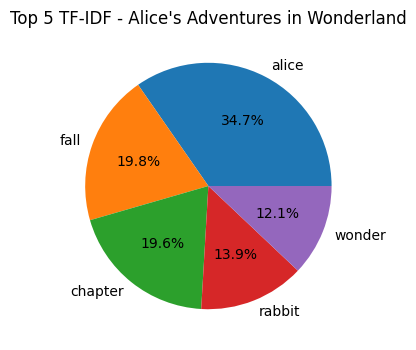

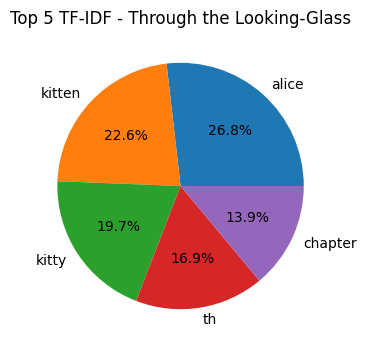

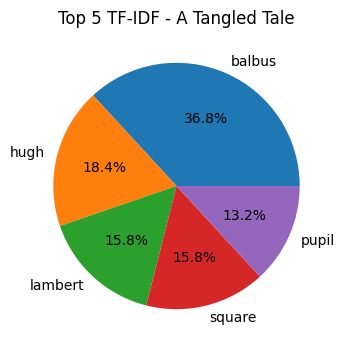

In [17]:
# 1. TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(min_df=1, max_df=2, stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform([' '.join(lemmas) for lemmas in all_lemmas])
feature_names_tfidf = tfidf_vec.get_feature_names_out()

# 2. Pie Plots with TF-IDF
for i, title in enumerate(titles):
    scores = tfidf_matrix[i].toarray().flatten()
    top_5_tfidf = scores.argsort()[-5:][::-1]

    plt.figure(figsize=(6, 4))
    plt.pie(scores[top_5_tfidf], labels=feature_names_tfidf[top_5_tfidf], autopct='%1.1f%%')
    plt.title(f"Top 5 TF-IDF - {title}")
    plt.show()